In [17]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os

pd.set_option('display.max_columns', None)

In [18]:
test = json.loads(open('../info.json', 'r', encoding='utf-8').read()).get('test') 
test

1

# DADOS MEASURE

,wz,az,yaw,ax,h,time,pitch,ay,wx,wy,roll,tmp
0,-2252.0,997978.0,1551.0,-17718.0,-0.024,7.152557e-07,-1548.0,-27586.0,-4969.0,10067.0,1043.0,43.8
1,-236.0,997271.0,1565.0,-17492.0,-0.022,9.435034e-02,-1546.0,-26316.0,7862.0,1753.0,1038.0,43.7
2,-4887.0,998455.0,1572.0,-16066.0,-0.019,2.007830e-01,-1549.0,-25342.0,-11278.0,-6852.0,1032.0,43.8
3,-1132.0,996125.0,1578.0,-17288.0,-0.017,2.974703e-01,-1549.0,-28140.0,-4654.0,3072.0,1031.0,43.7
4,-2012.0,997464.0,1592.0,-16452.0,-0.014,4.027123e-01,-1556.0,-27562.0,-709.0,-1811.0,1039.0,43.7
...,...,...,...,...,...,...,...,...,...,...,...,...
17022,-5596.0,998362.0,24694.0,-19961.0,-0.006,1.702951e+03,-1469.0,-24936.0,-2678.0,9952.0,1171.0,44.6
17023,-10312.0,996488.0,24696.0,-20226.0,-0.006,1.703046e+03,-1468.0,-25822.0,-6341.0,4221.0,1172.0,44.8
17024,2902.0,997655.0,24698.0,-20662.0,-0.006,1.703146e+03,-1469.0,-25137.0,5080.0,4384.0,1171.0,44.7
17025,-1943.0,997035.0,24699.0,-19568.0,-0.006,1.703249e+03,-1470.0,-24066.0,-5271.0,-5613.0,1171.0,44.7


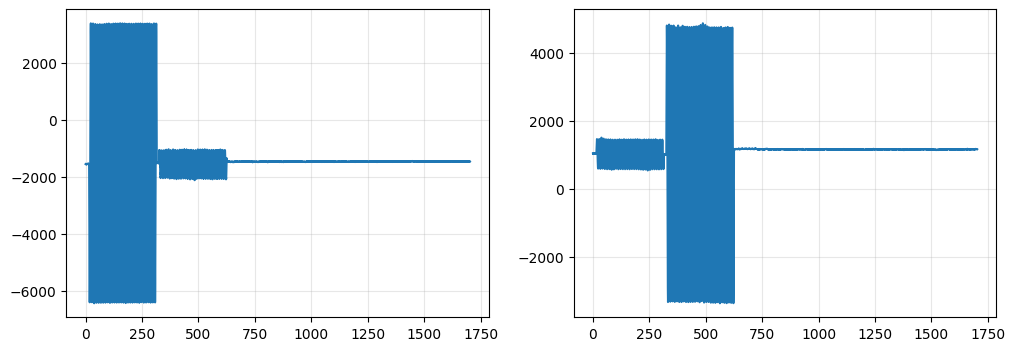

In [19]:
df_target = pd.read_csv(f'files/test{test}/target/data.csv')
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(df_target.time, df_target.pitch); plt.grid(alpha=.3)
plt.subplot(1, 2, 2)
plt.plot(df_target.time, df_target.roll); plt.grid(alpha=.3)
df_target

# DADOS KONGSBERG

,wz,az,yaw,ax,h,time,pitch,ay,wx,wy,roll,tmp
0,-2252.0,997978.0,1551.0,-17718.0,-0.024,7.152557e-07,-1548.0,-27586.0,-4969.0,10067.0,1043.0,43.8
1,-236.0,997271.0,1565.0,-17492.0,-0.022,9.435034e-02,-1546.0,-26316.0,7862.0,1753.0,1038.0,43.7
2,-4887.0,998455.0,1572.0,-16066.0,-0.019,2.007830e-01,-1549.0,-25342.0,-11278.0,-6852.0,1032.0,43.8
3,-1132.0,996125.0,1578.0,-17288.0,-0.017,2.974703e-01,-1549.0,-28140.0,-4654.0,3072.0,1031.0,43.7
4,-2012.0,997464.0,1592.0,-16452.0,-0.014,4.027123e-01,-1556.0,-27562.0,-709.0,-1811.0,1039.0,43.7
...,...,...,...,...,...,...,...,...,...,...,...,...
17022,-5596.0,998362.0,24694.0,-19961.0,-0.006,1.702951e+03,-1469.0,-24936.0,-2678.0,9952.0,1171.0,44.6
17023,-10312.0,996488.0,24696.0,-20226.0,-0.006,1.703046e+03,-1468.0,-25822.0,-6341.0,4221.0,1172.0,44.8
17024,2902.0,997655.0,24698.0,-20662.0,-0.006,1.703146e+03,-1469.0,-25137.0,5080.0,4384.0,1171.0,44.7
17025,-1943.0,997035.0,24699.0,-19568.0,-0.006,1.703249e+03,-1470.0,-24066.0,-5271.0,-5613.0,1171.0,44.7


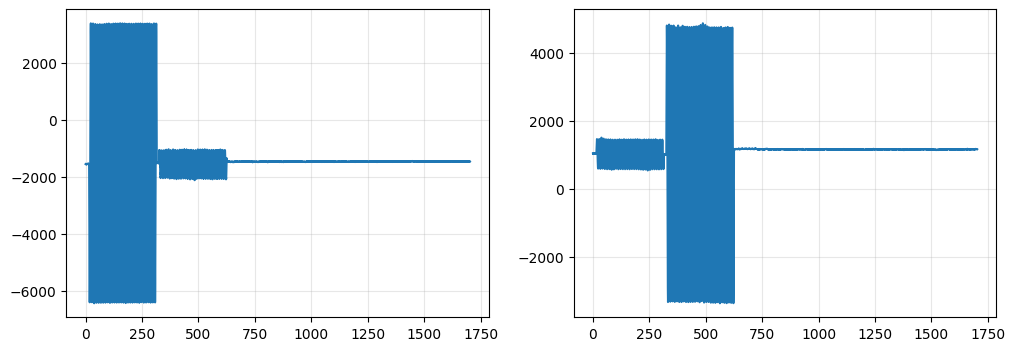

In [20]:
df_mru = pd.read_csv(f'files/test{test}/mru/data.csv')

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(df_mru.time, df_mru.pitch); plt.grid(alpha=.3)
plt.subplot(1, 2, 2)
plt.plot(df_mru.time, df_mru.roll); plt.grid(alpha=.3)
df_mru

# DADOS MESA

,wz,az,yaw,ax,h,time,pitch,ay,wx,wy,roll,tmp
0,0.0,9.8067,108.0,0.0,0.0,7.152557e-07,0.0,-0.0,0.0,0.0,0.0,0.000
1,0.0,9.8067,108.0,0.0,0.0,9.435034e-02,0.0,-0.0,0.0,0.0,0.0,0.100
2,0.0,9.8067,108.0,0.0,0.0,2.007830e-01,0.0,-0.0,0.0,0.0,0.0,0.200
3,0.0,9.8067,108.0,0.0,0.0,2.974703e-01,0.0,-0.0,0.0,0.0,0.0,0.300
4,0.0,9.8067,108.0,0.0,0.0,4.027123e-01,0.0,-0.0,0.0,0.0,0.0,0.400
...,...,...,...,...,...,...,...,...,...,...,...,...
17022,0.0,9.8067,108.0,0.0,0.0,1.702951e+03,0.0,-0.0,0.0,0.0,0.0,1702.935
17023,0.0,9.8067,108.0,0.0,0.0,1.703046e+03,0.0,-0.0,0.0,0.0,0.0,1703.035
17024,0.0,9.8067,108.0,0.0,0.0,1.703146e+03,0.0,-0.0,0.0,0.0,0.0,1703.135
17025,0.0,9.8067,108.0,0.0,0.0,1.703249e+03,0.0,-0.0,0.0,0.0,0.0,1703.235


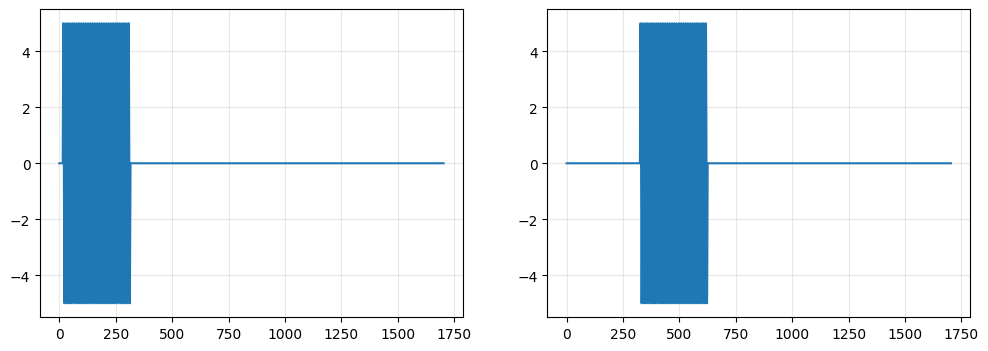

In [21]:
df_ref = pd.read_csv(f'files/test{test}/reference/data.csv')

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(df_ref.time, df_ref.pitch); plt.grid(alpha=.3)
plt.subplot(1, 2, 2)
plt.plot(df_ref.time, df_ref.roll); plt.grid(alpha=.3)
df_ref

# JUNTANDO TABELAS

In [22]:
df_target = df_target.rename(columns={col: 'target_' + col for col in df_target.columns if col not in ['time']})
df_target.head()

,target_wz,target_az,target_yaw,target_ax,target_h,time,target_pitch,target_ay,target_wx,target_wy,target_roll,target_tmp
0,-2252.0,997978.0,1551.0,-17718.0,-0.024,7.152557e-07,-1548.0,-27586.0,-4969.0,10067.0,1043.0,43.8
1,-236.0,997271.0,1565.0,-17492.0,-0.022,9.435034e-02,-1546.0,-26316.0,7862.0,1753.0,1038.0,43.7
2,-4887.0,998455.0,1572.0,-16066.0,-0.019,2.007830e-01,-1549.0,-25342.0,-11278.0,-6852.0,1032.0,43.8
3,-1132.0,996125.0,1578.0,-17288.0,-0.017,2.974703e-01,-1549.0,-28140.0,-4654.0,3072.0,1031.0,43.7
4,-2012.0,997464.0,1592.0,-16452.0,-0.014,4.027123e-01,-1556.0,-27562.0,-709.0,-1811.0,1039.0,43.7


In [23]:
df_mru = df_mru.rename(columns={col: 'mru_' + col for col in df_mru.columns if col not in ['time']})
df_mru.head()

,mru_wz,mru_az,mru_yaw,mru_ax,mru_h,time,mru_pitch,mru_ay,mru_wx,mru_wy,mru_roll,mru_tmp
0,-2252.0,997978.0,1551.0,-17718.0,-0.024,7.152557e-07,-1548.0,-27586.0,-4969.0,10067.0,1043.0,43.8
1,-236.0,997271.0,1565.0,-17492.0,-0.022,9.435034e-02,-1546.0,-26316.0,7862.0,1753.0,1038.0,43.7
2,-4887.0,998455.0,1572.0,-16066.0,-0.019,2.007830e-01,-1549.0,-25342.0,-11278.0,-6852.0,1032.0,43.8
3,-1132.0,996125.0,1578.0,-17288.0,-0.017,2.974703e-01,-1549.0,-28140.0,-4654.0,3072.0,1031.0,43.7
4,-2012.0,997464.0,1592.0,-16452.0,-0.014,4.027123e-01,-1556.0,-27562.0,-709.0,-1811.0,1039.0,43.7


In [24]:
df_ref = df_ref.rename(columns={col: 'ref_' + col for col in df_ref.columns if col not in ['time']})
df_ref.head()

,ref_wz,ref_az,ref_yaw,ref_ax,ref_h,time,ref_pitch,ref_ay,ref_wx,ref_wy,ref_roll,ref_tmp
0,0.0,9.8067,108.0,0.0,0.0,7.152557e-07,0.0,-0.0,0.0,0.0,0.0,0.0
1,0.0,9.8067,108.0,0.0,0.0,9.435034e-02,0.0,-0.0,0.0,0.0,0.0,0.1
2,0.0,9.8067,108.0,0.0,0.0,2.007830e-01,0.0,-0.0,0.0,0.0,0.0,0.2
3,0.0,9.8067,108.0,0.0,0.0,2.974703e-01,0.0,-0.0,0.0,0.0,0.0,0.3
4,0.0,9.8067,108.0,0.0,0.0,4.027123e-01,0.0,-0.0,0.0,0.0,0.0,0.4


In [25]:
df = pd.merge_asof(df_target, df_ref, on='time', direction='nearest')
df = pd.merge_asof(df, df_mru, on='time', direction='nearest')
df

,target_wz,target_az,target_yaw,target_ax,target_h,time,target_pitch,target_ay,target_wx,target_wy,target_roll,target_tmp,ref_wz,ref_az,ref_yaw,ref_ax,ref_h,ref_pitch,ref_ay,ref_wx,ref_wy,ref_roll,ref_tmp,mru_wz,mru_az,mru_yaw,mru_ax,mru_h,mru_pitch,mru_ay,mru_wx,mru_wy,mru_roll,mru_tmp
0,-2252.0,997978.0,1551.0,-17718.0,-0.024,7.152557e-07,-1548.0,-27586.0,-4969.0,10067.0,1043.0,43.8,0.0,9.8067,108.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.000,-2252.0,997978.0,1551.0,-17718.0,-0.024,-1548.0,-27586.0,-4969.0,10067.0,1043.0,43.8
1,-236.0,997271.0,1565.0,-17492.0,-0.022,9.435034e-02,-1546.0,-26316.0,7862.0,1753.0,1038.0,43.7,0.0,9.8067,108.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.100,-236.0,997271.0,1565.0,-17492.0,-0.022,-1546.0,-26316.0,7862.0,1753.0,1038.0,43.7
2,-4887.0,998455.0,1572.0,-16066.0,-0.019,2.007830e-01,-1549.0,-25342.0,-11278.0,-6852.0,1032.0,43.8,0.0,9.8067,108.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.200,-4887.0,998455.0,1572.0,-16066.0,-0.019,-1549.0,-25342.0,-11278.0,-6852.0,1032.0,43.8
3,-1132.0,996125.0,1578.0,-17288.0,-0.017,2.974703e-01,-1549.0,-28140.0,-4654.0,3072.0,1031.0,43.7,0.0,9.8067,108.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.300,-1132.0,996125.0,1578.0,-17288.0,-0.017,-1549.0,-28140.0,-4654.0,3072.0,1031.0,43.7
4,-2012.0,997464.0,1592.0,-16452.0,-0.014,4.027123e-01,-1556.0,-27562.0,-709.0,-1811.0,1039.0,43.7,0.0,9.8067,108.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.400,-2012.0,997464.0,1592.0,-16452.0,-0.014,-1556.0,-27562.0,-709.0,-1811.0,1039.0,43.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17022,-5596.0,998362.0,24694.0,-19961.0,-0.006,1.702951e+03,-1469.0,-24936.0,-2678.0,9952.0,1171.0,44.6,0.0,9.8067,108.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,1702.935,-5596.0,998362.0,24694.0,-19961.0,-0.006,-1469.0,-24936.0,-2678.0,9952.0,1171.0,44.6
17023,-10312.0,996488.0,24696.0,-20226.0,-0.006,1.703046e+03,-1468.0,-25822.0,-6341.0,4221.0,1172.0,44.8,0.0,9.8067,108.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,1703.035,-10312.0,996488.0,24696.0,-20226.0,-0.006,-1468.0,-25822.0,-6341.0,4221.0,1172.0,44.8
17024,2902.0,997655.0,24698.0,-20662.0,-0.006,1.703146e+03,-1469.0,-25137.0,5080.0,4384.0,1171.0,44.7,0.0,9.8067,108.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,1703.135,2902.0,997655.0,24698.0,-20662.0,-0.006,-1469.0,-25137.0,5080.0,4384.0,1171.0,44.7
17025,-1943.0,997035.0,24699.0,-19568.0,-0.006,1.703249e+03,-1470.0,-24066.0,-5271.0,-5613.0,1171.0,44.7,0.0,9.8067,108.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,1703.235,-1943.0,997035.0,24699.0,-19568.0,-0.006,-1470.0,-24066.0,-5271.0,-5613.0,1171.0,44.7


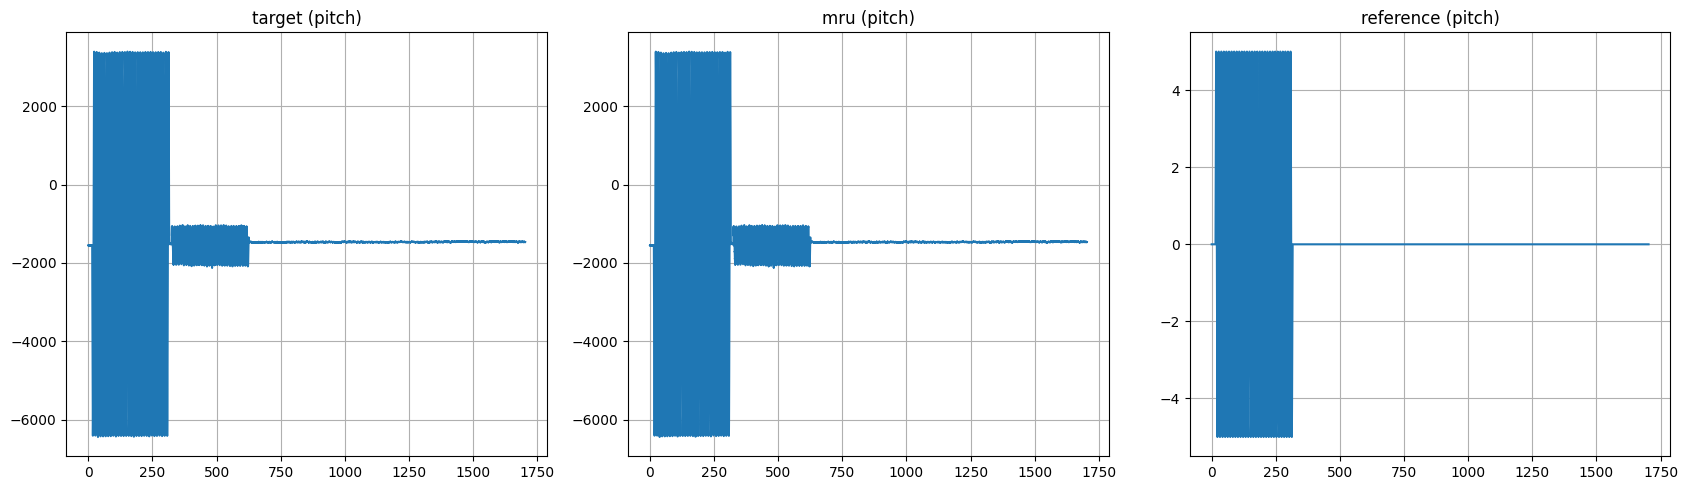

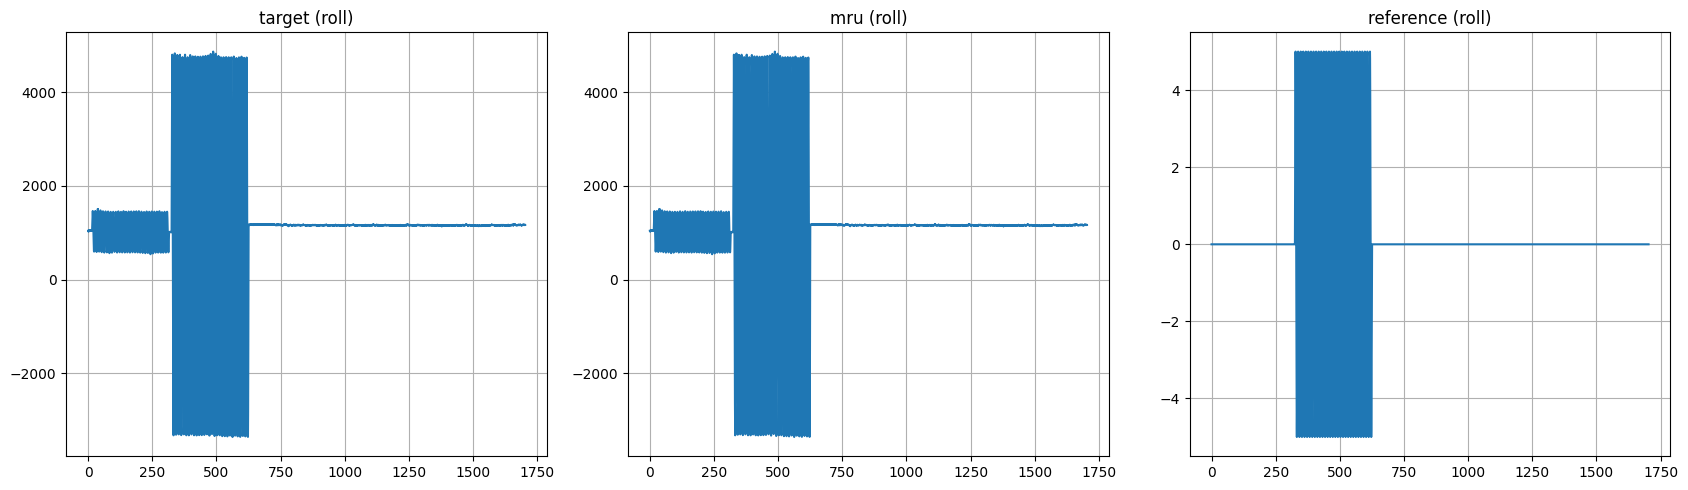

In [26]:
def compareAxis(data, time=None, figsize=None):
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)   
    plt.figure(figsize=figsize if figsize is not None else (6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        time_data = time if time is not None else np.array(range(len(values)))
        
        plt.subplot(numRows, numCols, i+1)
        plt.plot(time_data, values)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()


for var in ['pitch', 'roll']:
    compareAxis({
        f'target ({var})':  df[f'target_{var}'], 
        f'mru ({var})': df[f'mru_{var}'],
        f'reference ({var})': df[f'ref_{var}'],
    }, time=df.time, figsize=(17, 5))

# ENCONTRANDO CATEGORIAS
- status pode ser = 'none' (nenhum/estabilizando), 'pitch' (variando pitch), 'roll' (variando roll), 'static' (parado)
- Implementação da detecção pelos dados utilizando os intervalos com folgas de 10s:

In [27]:
conditions = [
    (df['time'] >= 15) & (df['time'] < 315),  # 300s variando pitch
    (df['time'] >= 325) & (df['time'] < 625), # 300s variando roll
    (df['time'] >= 635)                       # estático (parado)
]

choices = ['pitch', 'roll', 'static']
df['status'] = np.select(conditions, choices, default='none')
df['status'].value_counts()

status
static    10679
pitch      3000
roll       2998
none        350
Name: count, dtype: int64

# SALVANDO DADOS

In [28]:
os.makedirs('files', exist_ok=True)
df.to_csv('files/output.csv', index=None)